### T evaluation


In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "settings.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "models" / "modified-classification"
ROOT = NOTEBOOK_DIR.parents[1]
for p in (ROOT, NOTEBOOK_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from _helpers import check_settings_hash, resolve_run_dir, settings_hash
from settings import OUTPUTS_DIR

RUN_DIR = resolve_run_dir(OUTPUTS_DIR)
check_settings_hash(RUN_DIR)
print(f"settings.py matches run {RUN_DIR.name} ({settings_hash()[:12]}…)")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from model_m import MetricPredictor
from model_t import (
    TimestepPredictor,
    gate_metrics,
    load_timestep_predictor,
    per_image_spearman,
    regret,
)
from _data import df_to_metric_grids, load_run_splits, precompute_embeddings, target_bounds
from _helpers import add_combined_score, resolve_device, scalarize
from settings import *


settings.py matches run 20260713_104756 (95198bdf57ea…)


/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Optional override: RUN_DIR = NOTEBOOK_DIR / "outputs" / "..." / "20260709_144025"
print(f"Run: {RUN_DIR.name} in {RUN_DIR.parent.name}")


Run: 20260713_104756 in UltraEdit_Region_10


In [3]:
PLOT_SPLIT = "test"
splits = load_run_splits(RUN_DIR)
train_df, val_df, test_df = splits["train"], splits["val"], splits["test"]
full_df = pd.concat(splits.values(), ignore_index=True)
print(f"Run: {RUN_DIR.name}  " + "  ".join(
    f"{name}={len(df)} cells ({df[SAMPLE_ID_COL].nunique()} samples)" for name, df in splits.items()
))


Run: 20260713_104756  train=968 cells (8 samples)  val=121 cells (1 samples)  test=121 cells (1 samples)


In [4]:
true_df = full_df.sort_values([SAMPLE_ID_COL, T_START_COL, T_END_COL]).reset_index(drop=True)
bounds = target_bounds()
true_df[T_TARGET_COL] = add_combined_score(true_df, bounds)
true_argmax_df = true_df.loc[true_df.groupby(SAMPLE_ID_COL)[T_TARGET_COL].idxmax()].reset_index(drop=True)
print(f"Found metrics for {len(true_df)} grid cells for {true_df[SAMPLE_ID_COL].nunique()} samples")
print(f"Found (t_start, t_end) argmax for {T_TARGET_COL} for {len(true_argmax_df)} samples")
true_argmax_df.head()


Found metrics for 1210 grid cells for 10 samples
Found (t_start, t_end) argmax for combined_score for 10 samples


,sample_id,t_start,t_end,t_delta,psnr,clip_similarity_target_image_edit_part,source_prompt,target_prompt,image_path,mask_image_path,combined_score
0,00000000,0.0,0.0,0.0,26.815052,19.001621,A person driving a 4 wheeler after a [herd] of...,A person driving a 4 wheeler after a [flock] o...,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,0.567690
1,00000001,0.2,0.0,0.0,28.252775,17.415043,An old man looking over a tray of [sandwiches].,An old man looking over a tray of [cupcakes].,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,0.568532
2,00000002,0.1,0.0,0.0,28.128862,14.970240,A billboard that says '[keep sheffield moving]...,A billboard that says '[embrace change]' on it.,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,0.522314
3,00000003,0.0,0.0,0.0,32.568634,20.843113,A large herd of [goats] crossing a street to f...,A large herd of [zebras] crossing a street to ...,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,0.717470
4,00000004,0.3,0.2,0.0,24.275650,19.438099,A cat sleeping on the ground using a [shoe] as...,A cat sleeping on the ground using a [miniatur...,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,/shared/ssd_30T/mirick/datasets/ultra_edit/Ult...,0.523913


In [5]:
GPU = None
DEVICE = resolve_device(GPU)
print(f"device: {DEVICE}")


device: cuda


In [6]:
timestep_predictor = load_timestep_predictor(RUN_DIR / "regressor_weights.pt", device=DEVICE)
embed_df = full_df.drop_duplicates(SAMPLE_ID_COL).copy().reset_index(drop=True)
input_embeddings = precompute_embeddings(embed_df, timestep_predictor.m, DEVICE)

pred_rows = []
for sid, emb in input_embeddings.items():
    grid = timestep_predictor.predict_grid_from_emb(emb["img"], emb["mask"], emb["src"], emb["tar"])
    ts, te = np.meshgrid(grid.t_start_values, grid.t_end_values, indexing="ij")
    pred_psnr = grid.psnr_grid.ravel()
    pred_clip = grid.clip_grid.ravel()
    for k in range(ts.size):
        pred_rows.append({
            SAMPLE_ID_COL: sid,
            T_START_COL: float(ts.ravel()[k]),
            T_END_COL: float(te.ravel()[k]),
            PSNR_COL: pred_psnr[k],
            CLIP_COL: pred_clip[k],
        })

pred_df = pd.DataFrame(pred_rows).sort_values([SAMPLE_ID_COL, T_START_COL, T_END_COL]).reset_index(drop=True)
pred_df[T_TARGET_COL] = add_combined_score(pred_df, bounds, already_normalized=True)
print(f"Predicted metrics for {len(pred_df)} grid cells for {pred_df[SAMPLE_ID_COL].nunique()} samples")
pred_argmax_df = pred_df.loc[pred_df.groupby(SAMPLE_ID_COL)[T_TARGET_COL].idxmax()].reset_index(drop=True)
print(f"Predicted (t_start, t_end) argmax for {T_TARGET_COL} for {len(pred_argmax_df)} samples")
pred_argmax_df.head()


Loading weights: 100%|██████████| 372/372 [00:00<00:00, 9883.77it/s]


Predicted metrics for 1210 grid cells for 10 samples
Predicted (t_start, t_end) argmax for combined_score for 10 samples


,sample_id,t_start,t_end,psnr,clip_similarity_target_image_edit_part,combined_score
0,00000000,1.0,1.0,0.128545,0.818708,0.473627
1,00000001,0.3,0.0,0.730795,0.273703,0.502249
2,00000002,0.3,0.0,0.761828,0.205117,0.483472
3,00000003,0.3,0.0,0.850013,0.349977,0.599995
4,00000004,0.3,0.0,0.799227,0.113756,0.456491


In [7]:
eval_df = splits[PLOT_SPLIT]
SAMPLE_IDS = sorted(eval_df[SAMPLE_ID_COL].unique())
N_IMG = len(SAMPLE_IDS)
T_START_VALUES = np.asarray(sorted(eval_df[T_START_COL].unique()), dtype=np.float64)
T_END_VALUES = np.asarray(sorted(eval_df[T_END_COL].unique()), dtype=np.float64)
N1, N2 = len(T_START_VALUES), len(T_END_VALUES)
CELLS = N1 * N2
T_START_DELTA = int(np.argmin(np.abs(T_START_VALUES - DEFAULT_T_START)))
T_END_DELTA = int(np.argmin(np.abs(T_END_VALUES - DEFAULT_T_END)))

true_psnr, _ = df_to_metric_grids(eval_df, SAMPLE_IDS, T_START_VALUES, T_END_VALUES, PSNR_COL)
true_clip, _ = df_to_metric_grids(eval_df, SAMPLE_IDS, T_START_VALUES, T_END_VALUES, CLIP_COL)
true_m = scalarize(true_psnr, true_clip, bounds)

pred_psnr = np.zeros_like(true_psnr)
pred_clip = np.zeros_like(true_clip)
pred_m = np.zeros_like(true_m)
for sid in SAMPLE_IDS:
    k = SAMPLE_IDS.index(sid)
    grid = timestep_predictor.predict_grid_from_emb(
        input_embeddings[sid]["img"],
        input_embeddings[sid]["mask"],
        input_embeddings[sid]["src"],
        input_embeddings[sid]["tar"],
    )
    pred_psnr[k], pred_clip[k], pred_m[k] = grid.psnr_grid, grid.clip_grid, grid.m_grid

print(f"default cell ({T_START_DELTA}, {T_END_DELTA}) -> t_start={T_START_VALUES[T_START_DELTA]:.3g}, t_end={T_END_VALUES[T_END_DELTA]:.3g}")
print(f"{PLOT_SPLIT} grids: {true_m.shape}")


default cell (9, 3) -> t_start=0.9, t_end=0.3
test grids: (1, 11, 11)


In [ ]:
def fig_title(subtitle: str, split: str) -> str:
    return f"{subtitle} on {METRICS_CSV.stem} for {T_TARGET_COL}, $\\delta={{{TARGET_T_DELTA:.2f}}}$ ({split})"


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3160851/2558314824.py:2: SyntaxWarning: invalid escape sequence '\d'
  return f"{subtitle} on {METRICS_CSV.stem} for {T_TARGET_COL}, $\delta={{{TARGET_T_DELTA:.2f}}}$ ({split})"


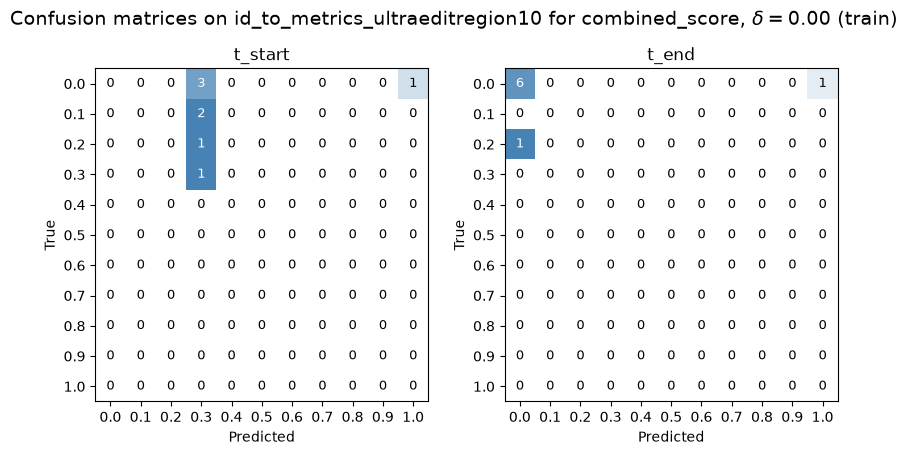

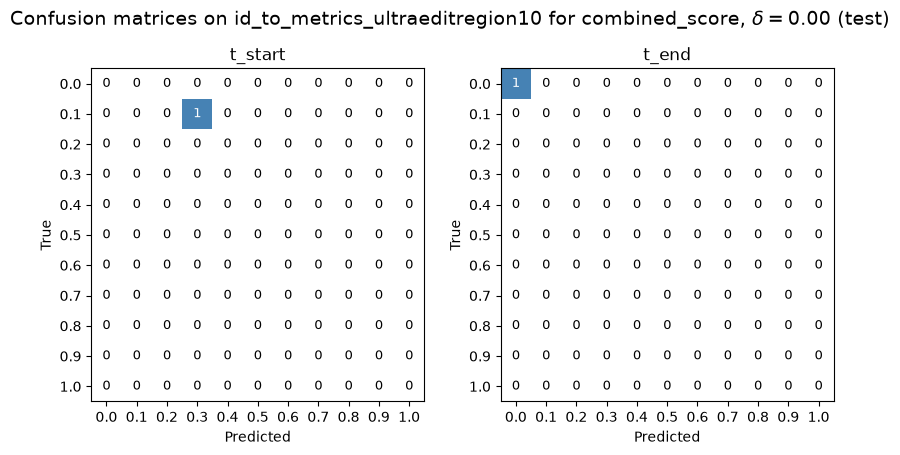

In [9]:
"""
Plot row-normalised confusion matrices for both heads across all three splits. Each cell
shows the raw count as a number and is shaded by the fraction of true-class samples that
fell in that predicted bucket, making it easy to see whether errors cluster near the
diagonal (near-miss) or scatter widely (large mistakes).
"""
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

cmp_df = true_argmax_df[[SAMPLE_ID_COL, T_START_COL, T_END_COL]].merge(
    pred_argmax_df[[SAMPLE_ID_COL, T_START_COL, T_END_COL]],
    on=SAMPLE_ID_COL,
    suffixes=("_true", "_pred"),
)
for col in (T_START_COL, T_END_COL):
    cmp_df[f"{col}_true"] = cmp_df[f"{col}_true"].astype(float)
    cmp_df[f"{col}_pred"] = cmp_df[f"{col}_pred"].astype(float)

BUCKET_LABELS_START = [f"{v:.1f}" for v in GRID_T_START]
BUCKET_LABELS_END = [f"{v:.1f}" for v in GRID_T_END]
t_start_to_idx = {float(v): i for i, v in enumerate(GRID_T_START)}
t_end_to_idx = {float(v): i for i, v in enumerate(GRID_T_END)}

results = {}
for split_name, split_df in splits.items():
    split_cmp = cmp_df[cmp_df[SAMPLE_ID_COL].isin(split_df[SAMPLE_ID_COL].unique())]
    results[split_name] = {
        "true_start": split_cmp[f"{T_START_COL}_true"].map(t_start_to_idx).to_numpy(),
        "pred_start": split_cmp[f"{T_START_COL}_pred"].map(t_start_to_idx).to_numpy(),
        "true_end": split_cmp[f"{T_END_COL}_true"].map(t_end_to_idx).to_numpy(),
        "pred_end": split_cmp[f"{T_END_COL}_pred"].map(t_end_to_idx).to_numpy(),
    }

cmap = LinearSegmentedColormap.from_list("wb", ["white", "steelblue"])

def plot_confusion(ax, true, pred, title, bucket_labels):
    # Plot confusion matrix for t_start and t_end
    n_buckets = len(bucket_labels)
    cm = confusion_matrix(true, pred, labels=list(range(n_buckets)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    for i in range(n_buckets):
        for j in range(n_buckets):
            ax.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center", fontsize=9,
                color="white" if cm_norm[i, j] > 0.5 else "black",
            )
    ax.set_xticks(range(n_buckets))
    ax.set_yticks(range(n_buckets))
    ax.set_xticklabels(bucket_labels)
    ax.set_yticklabels(bucket_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    return im

def plot_split(split):
    # Create separate confusion matrices for t_start and t_end
    r = results[split]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
    plot_confusion(axes[0], r["true_start"], r["pred_start"], f"t_start", BUCKET_LABELS_START)
    plot_confusion(axes[1], r["true_end"], r["pred_end"], f"t_end", BUCKET_LABELS_END)
    for ax in axes:
        ax.tick_params(axis="y", labelleft=True)
        ax.set_ylabel("True")
    fig.suptitle(fig_title("Confusion matrices", split), fontsize=14)
    fig.subplots_adjust(wspace=0.12, top=0.85)
    plt.show()
    plt.close(fig)

for split in ["train", "test"]:
    plot_split(split)

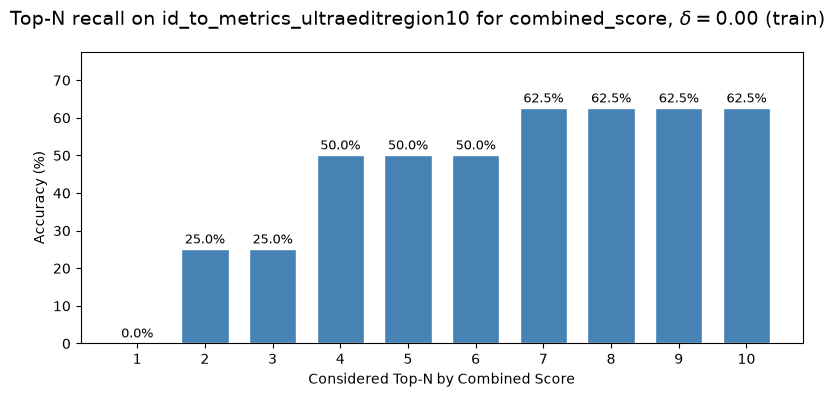

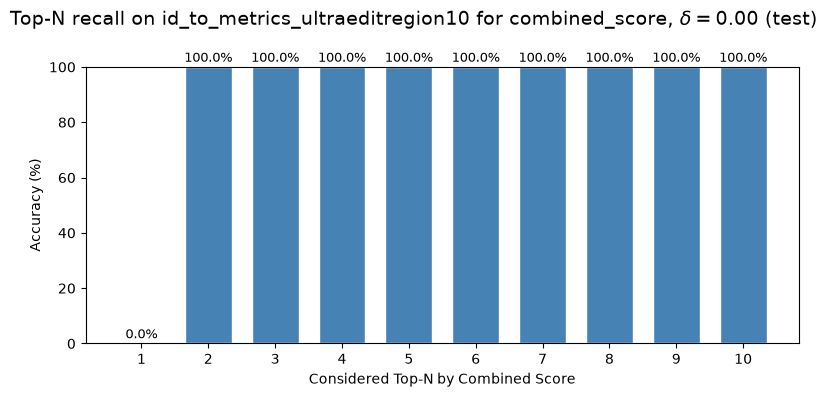

In [10]:
# Top-N accuracy, is the true-best cell in the model's top-N predictions by T_TARGET_COL?

def true_best_in_top_n_pct(true_df, pred_df, n_values):
    """Percent of samples whose oracle argmax is inside pred top-N (by T_TARGET_COL)."""
    true_best = true_df.loc[
        true_df.groupby(SAMPLE_ID_COL)[T_TARGET_COL].idxmax(),
        [SAMPLE_ID_COL, T_START_COL, T_END_COL],
    ]
    n_img = len(true_best)
    out = []
    for n in n_values:
        hits = 0
        for row in true_best.itertuples():
            pred_top = pred_df[pred_df[SAMPLE_ID_COL] == row.sample_id].nlargest(n, T_TARGET_COL)
            pred_cells = set(zip(pred_top[T_START_COL].astype(float), pred_top[T_END_COL].astype(float)))
            true_cell = (float(getattr(row, T_START_COL)), float(getattr(row, T_END_COL)))
            hits += true_cell in pred_cells
        out.append(100.0 * hits / n_img)
    return np.array(out)


def plot_top_n_recall(split_name, split_df):
    split_ids = split_df[SAMPLE_ID_COL].unique()
    split_true_df = true_df[true_df[SAMPLE_ID_COL].isin(split_ids)]
    split_pred_df = pred_df[pred_df[SAMPLE_ID_COL].isin(split_ids)]

    top_k = np.arange(1, 11)
    n_cells = split_pred_df.groupby(SAMPLE_ID_COL).size().iloc[0]
    top_k_acc = true_best_in_top_n_pct(split_true_df, split_pred_df, top_k)
    x_labels = [f"{n}" for n in top_k] # \n({100.0 * n / n_cells:.1f}%)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(top_k, top_k_acc, color="steelblue", edgecolor="white", width=0.7)
    ax.set_xlabel(f"Considered Top-N by {T_TARGET_LABEL}")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(top_k)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, min(100, top_k_acc.max() + 15))
    for bar, pct in zip(bars, top_k_acc):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    fig.suptitle(fig_title("Top-N recall", split_name), fontsize=14)
    plt.tight_layout()
    plt.show()


for split_name, split_df in [("train", train_df), ("test", test_df)]:
    plot_top_n_recall(split_name, split_df)


In [11]:
# Metric summaries on test, plus deltas vs default.
from IPython.display import display

METRICS = [PSNR_COL, CLIP_COL, T_TARGET_COL]
STATS = ["mean", "median", "std", "min", "max"]
test_ids = set(test_df[SAMPLE_ID_COL].unique())

def metric_rows(df):
    out = df[df[SAMPLE_ID_COL].isin(test_ids)][[SAMPLE_ID_COL, *METRICS]].copy()
    out[METRICS] = out[METRICS].apply(pd.to_numeric)
    return out.set_index(SAMPLE_ID_COL)

default = true_df[
    np.isclose(true_df[T_START_COL].astype(float), DEFAULT_T_START)
    & np.isclose(true_df[T_END_COL].astype(float), DEFAULT_T_END)
]
default, true_best, pred_best = map(metric_rows, [default, true_argmax_df, pred_argmax_df])

# Create deltas columns.
selections = {"Default": default, "True Best": true_best, "Pred Best": pred_best}
values = {name: df.agg(STATS) for name, df in selections.items()}
deltas = {
    "Δ True Best": (true_best - default).agg(STATS),
    "Δ Pred Best": (pred_best - default).agg(STATS),
    "Δ Pred True": (pred_best - true_best).agg(STATS),
}
columns = ["Default", "True Best", "Δ True Best", "Pred Best", "Δ Pred Best", "Δ Pred True"]

print(fig_title("Comparative stats", "test"))
for metric in METRICS:
    # Create a table with the specified columns.
    table = pd.DataFrame({
        "Default": values["Default"][metric],
        "True Best": values["True Best"][metric],
        "Δ True Best": deltas["Δ True Best"][metric],
        "Pred Best": values["Pred Best"][metric],
        "Δ Pred Best": deltas["Δ Pred Best"][metric],
        "Δ Pred True": deltas["Δ Pred True"][metric],
    })[columns]
    # Format the table with the specified column formatting.
    print("\n", metric)
    display(table.style.format({
        col: ("{:+.3f}" if col.startswith("Δ") else "{:.3f}") for col in columns
    }))

Comparative stats on id_to_metrics_ultraeditregion10 for combined_score, $\delta={0.00}$ (test)

 psnr


,Default,True Best,Δ True Best,Pred Best,Δ Pred Best,Δ Pred True
mean,19.543,33.142,+13.600,0.792,-18.750,-32.350
median,19.543,33.142,+13.600,0.792,-18.750,-32.350
std,nan,nan,+nan,nan,+nan,+nan
min,19.543,33.142,+13.600,0.792,-18.750,-32.350
max,19.543,33.142,+13.600,0.792,-18.750,-32.350



 clip_similarity_target_image_edit_part


,Default,True Best,Δ True Best,Pred Best,Δ Pred Best,Δ Pred True
mean,16.931,21.211,+4.280,0.317,-16.614,-20.894
median,16.931,21.211,+4.280,0.317,-16.614,-20.894
std,nan,nan,+nan,nan,+nan,+nan
min,16.931,21.211,+4.280,0.317,-16.614,-20.894
max,16.931,21.211,+4.280,0.317,-16.614,-20.894



 combined_score


,Default,True Best,Δ True Best,Pred Best,Δ Pred Best,Δ Pred True
mean,0.383,0.736,+0.353,0.555,+0.172,-0.181
median,0.383,0.736,+0.353,0.555,+0.172,-0.181
std,nan,nan,+nan,nan,+nan,+nan
min,0.383,0.736,+0.353,0.555,+0.172,-0.181
max,0.383,0.736,+0.353,0.555,+0.172,-0.181


PSNR   median rho=0.985  frac<0.2=0.00  frac<0=0.00
CLIP   median rho=0.540  frac<0.2=0.00  frac<0=0.00
m      median rho=0.927  frac<0.2=0.00  frac<0=0.00


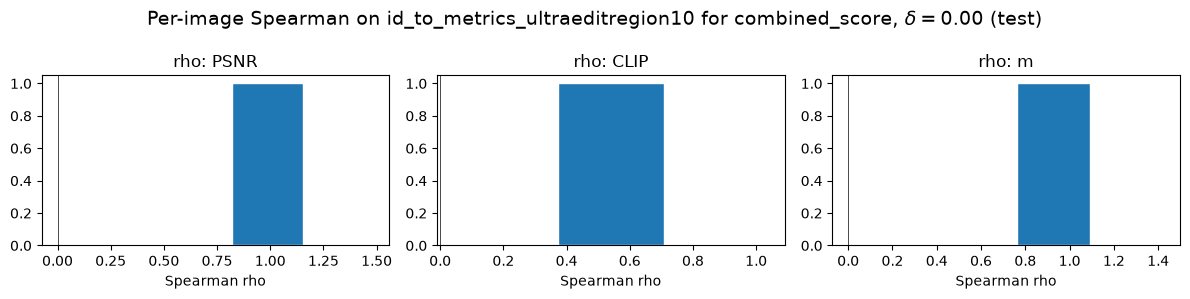

In [12]:

"""
Per-image Spearman rho — does M rank grid cells correctly within each image?

For each image, correlate the ranked order of true vs predicted values across
all 121 cells. Reported for PSNR, CLIP, and scalarized m separately.

Interpretation:
  - median rho > 0.5   -> strong within-image ranking; T argmax is well-founded.
  - median rho 0.2-0.5 -> weak but nonzero signal; expect moderate regret.
  - median rho < 0.2   -> near-random ranking; T selection is unreliable.
  - frac rho < 0       -> fraction of images where M ranks backwards; should be ~0.
  - rho(m) matters most since T argmax operates on m, not raw PSNR/CLIP alone.
  - High rho(PSNR) but low rho(CLIP) -> check scalarization weights in settings.py.
"""

rho_psnr = per_image_spearman(true_psnr, pred_psnr)
rho_clip = per_image_spearman(true_clip, pred_clip)
rho_m = per_image_spearman(true_m, pred_m)
for name, r in [("PSNR", rho_psnr), ("CLIP", rho_clip), ("m", rho_m)]:
    rv = r[np.isfinite(r)]
    print(f"{name:5s}  median rho={np.nanmedian(r):.3f}  frac<0.2={np.mean(rv < 0.2):.2f}  frac<0={np.mean(rv < 0):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (name, r) in zip(axes, [("PSNR", rho_psnr), ("CLIP", rho_clip), ("m", rho_m)]):
    rv = r[np.isfinite(r)]
    if len(rv): ax.hist(rv, bins=min(30, max(3, len(rv))), edgecolor="white")
    ax.axvline(0, color="k", lw=0.5); ax.set_title(f"rho: {name}"); ax.set_xlabel("Spearman rho")
fig.suptitle(fig_title("Per-image Spearman", PLOT_SPLIT), fontsize=14); plt.tight_layout(); plt.show()


regret  median=0.0181  p90=0.0181  frac~0=0.00


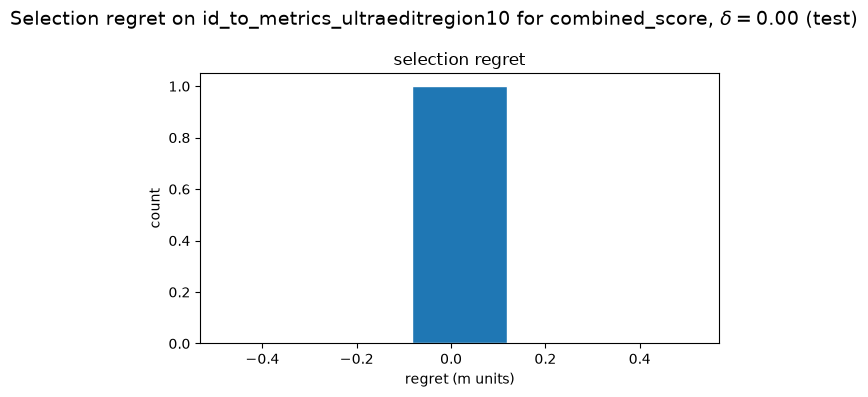

In [13]:

"""
Selection regret — how much true m do we lose by following argmax(pred_m)?

regret = true_m[oracle cell] - true_m[cell chosen by T]
Lower is better. Zero means T picked the true-best cell.

Interpretation:
  - median regret ~ 0, frac~0 high  -> T matches oracle on most images.
  - median regret < noise floor    -> gains are within label noise; defaults may suffice.
  - median regret >> noise floor   -> T is leaving real quality on the table.
  - p90 regret much larger than median -> a few images have catastrophic mis-selection.
  - Compare regret median to NOISE_FLOOR_M to judge practical significance.
"""

reg = regret(true_m, pred_m)
print(f"regret  median={np.median(reg):.4f}  p90={np.percentile(reg, 90):.4f}  frac~0={np.mean(reg < 1e-3):.2f}")
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(reg, bins=min(30, max(5, N_IMG // 2)), edgecolor="white")
ax.set_xlabel("regret (m units)"); ax.set_ylabel("count"); ax.set_title("selection regret")
fig.suptitle(fig_title("Selection regret", PLOT_SPLIT), fontsize=14); plt.tight_layout(); plt.show()


In [14]:

"""
Top-1 hit rate and top-3 overlap — does argmax(pred) land on the true best cell?

top-1 hit rate: fraction of images where pred argmax == true argmax (exact match).
top-3 overlap:  fraction of the true top-3 cells that also appear in pred top-3.

Interpretation:
  - hit rate > 0.3 on a 121-cell grid  -> better than chance (~0.008); promising.
  - hit rate > 0.5                     -> strong exact-match performance.
  - high top-3 overlap, low hit rate   -> M finds the right region but not exact peak.
  - both near 0                        -> ranking failure; check Spearman and surface plots.
  - top-3 overlap is more forgiving; useful when near-optimal cells are interchangeable.
"""

def topk_metrics(true_m_grid, pred_m_grid, k=3):
    hit1, ov = [], []
    for i in range(true_m_grid.shape[0]):
        t_order = true_m_grid[i].ravel().argsort()[::-1]
        p_order = pred_m_grid[i].ravel().argsort()[::-1]
        hit1.append(t_order[0] == p_order[0])
        ov.append(len(set(t_order[:k]) & set(p_order[:k])) / k)
    return np.mean(hit1), np.mean(ov)

h1, ov3 = topk_metrics(true_m, pred_m, k=3)
print(f"top-1 hit rate={h1:.3f}   top-3 overlap={ov3:.3f}")


top-1 hit rate=0.000   top-3 overlap=0.333


### Top-N recall — is the true-best cell among T's top-N predicted outputs?

For each N, plot the percent of images whose oracle-best `(t_start, t_end)` cell appears in T's top-N cells ranked by predicted `m`.

**Interpretation**
- Steep rise in the first few N → T ranks the true best near the top quickly.
- Flat near 0 for small N → ranking failure; true best is rarely highly ranked.
- At N=1, equals top-1 hit rate; at N=121, must reach 100%.

In [15]:
def true_best_in_top_n_pct(true_m_grid, pred_m_grid, n_values):
    """Percent of images with oracle argmax inside pred top-N (by m)."""
    n_img = true_m_grid.shape[0]
    out = []
    for n in n_values:
        hits = 0
        for i in range(n_img):
            t_order = true_m_grid[i].ravel().argsort()[::-1]
            p_order = pred_m_grid[i].ravel().argsort()[::-1]
            if t_order[0] in p_order[:n]:
                hits += 1
        out.append(100.0 * hits / n_img)
    return np.array(out)

In [16]:
n_values = np.arange(1, CELLS + 1)
top_n_pct = true_best_in_top_n_pct(true_m, pred_m, n_values)

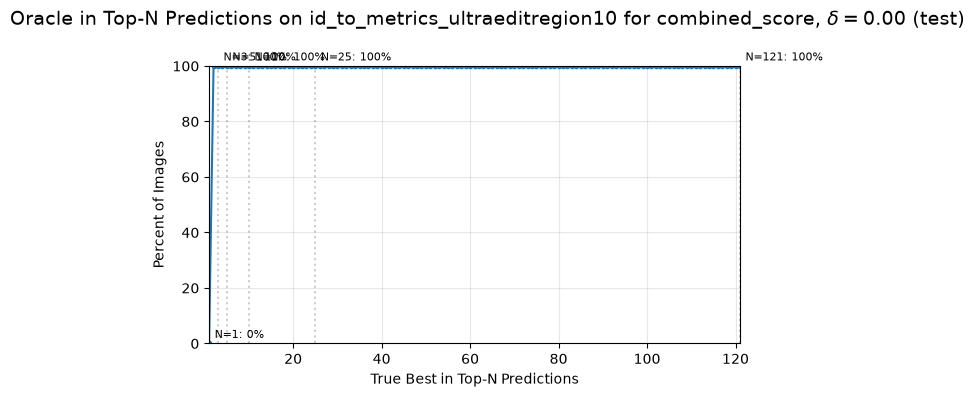

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_values, top_n_pct, marker="o", markersize=3, linewidth=1.5)
ax.set_xlabel("True Best in Top-N Predictions")
ax.set_ylabel("Percent of Images")
ax.set_xlim(1, CELLS)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
for n_mark in (1, 3, 5, 10, 25, CELLS):
    pct = top_n_pct[n_mark - 1]
    ax.axvline(n_mark, color="k", linestyle=":", alpha=0.2)
    ax.annotate(f"N={n_mark}: {pct:.0f}%", xy=(n_mark, pct), xytext=(4, 4),
                textcoords="offset points", fontsize=8)
fig.suptitle(fig_title("Oracle in Top-N Predictions", PLOT_SPLIT), fontsize=14)
plt.tight_layout(); plt.show()

In [18]:
print(f"top-1={top_n_pct[0]:.1f}%  top-3={top_n_pct[2]:.1f}%  top-10={top_n_pct[9]:.1f}%  top-25={top_n_pct[24]:.1f}%")

top-1=0.0%  top-3=100.0%  top-10=100.0%  top-25=100.0%


true argmax spread = 0.000
pred argmax spread = 0.000
unique pred cells = 1 / 121


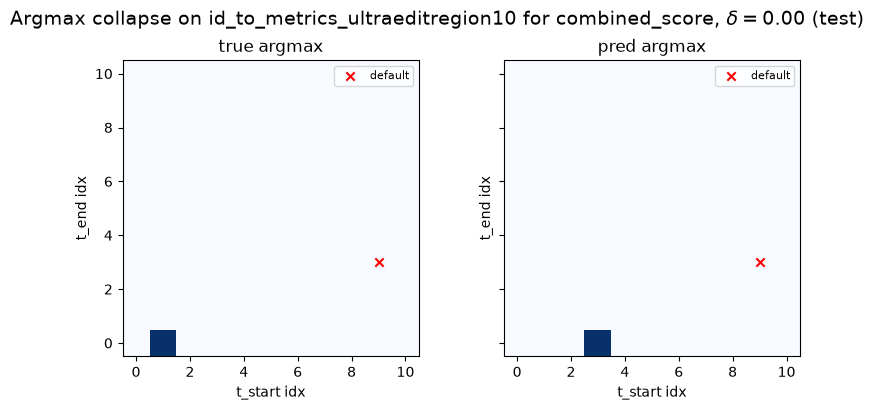

In [19]:

"""
Argmax collapse — does T pick diverse cells or always the same (t_start, t_end)?

Compare the spatial spread of true vs predicted argmax cells across images.
Red X marks the paper-default cell (t_start=0.9, t_end=0.3).

Interpretation:
  - pred spread ~ true spread, many unique pred cells -> T adapts per image (good).
  - pred spread << true spread                       -> collapse; M surface is too flat.
  - unique pred cells = 1-2 out of 121               -> T ignores image content entirely.
  - pred mass on default cell while true is spread   -> gate may be too conservative.
  - pred mass at grid edges while true is interior   -> M may overfit boundary artifacts.
"""

def argmax_cells(grid):
    return np.array([np.unravel_index(grid[k].argmax(), grid[k].shape) for k in range(grid.shape[0])])

true_arg = argmax_cells(true_m)
pred_arg = argmax_cells(pred_m)

def spread(arg):
    return arg[:, 0].std() + arg[:, 1].std()

print(f"true argmax spread = {spread(true_arg):.3f}")
print(f"pred argmax spread = {spread(pred_arg):.3f}")
print(f"unique pred cells = {len(set(map(tuple, pred_arg)))} / {CELLS}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
for ax, arg, title in zip(axes, [true_arg, pred_arg], ["true argmax", "pred argmax"]):
    H = np.zeros((N1, N2))
    for i, j in arg: H[i, j] += 1
    ax.imshow(H.T, origin="lower", cmap="Blues"); ax.set_title(title)
    ax.scatter([T_START_DELTA], [T_END_DELTA], c="r", marker="x", label="default")
    ax.set_xlabel("t_start idx"); ax.set_ylabel("t_end idx"); ax.legend(fontsize=8)
fig.suptitle(fig_title("Argmax collapse", PLOT_SPLIT), fontsize=14); plt.tight_layout(); plt.show()


In [20]:
nf = NOISE_FLOOR_M
gate = gate_metrics(true_m, pred_m, T_START_DELTA, T_END_DELTA, nf)
print(
    f"gate  precision={gate['precision']:.3f}  recall={gate['recall']:.3f}  "
    f"({gate['n_flagged']} flagged of {N_IMG})  noise_floor={nf:.4f}"
)
precision = gate["precision"]
recall = gate["recall"]


gate  precision=1.000  recall=1.000  (1 flagged of 1)  noise_floor=0.0000


regret vs default quality corr: nan
regret by edge: {True: 0.018111268656350155}


/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


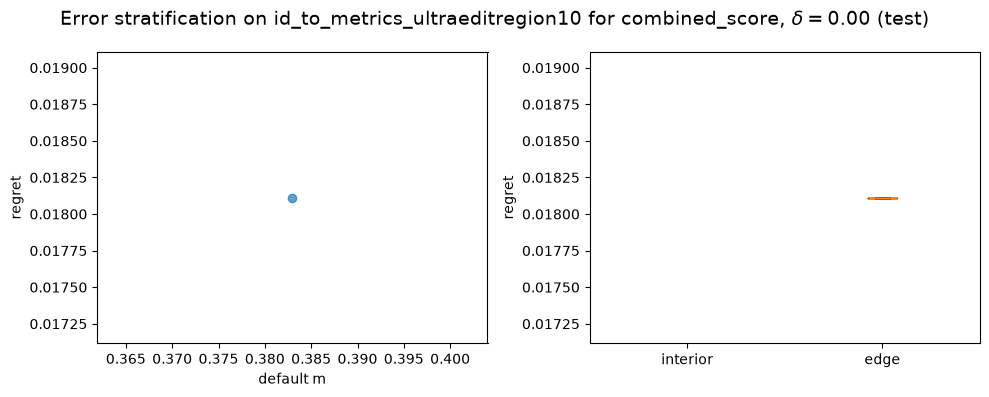

In [21]:

"""
Error stratification — where does T fail?

Relates regret to default-cell quality and whether the true optimum sits on the
grid boundary (t_start or t_end at 0.0 or 1.0).

Interpretation:
  - regret vs default_quality correlation near 0 -> errors are not driven by baseline quality.
  - higher regret when best_at_edge=True       -> M struggles at grid boundaries; expected if
      training data is sparse near edges.
  - higher regret when best_at_edge=False      -> interior ranking failure; more concerning.
  - scatter cluster at high regret, low default -> images where defaults are poor and T also fails.
"""

df_err = pd.DataFrame({
    "sample_id": SAMPLE_IDS,
    "regret": reg,
    "default_quality": true_m[:, T_START_DELTA, T_END_DELTA],
    "best_at_edge": [(i in (0, N1-1)) or (j in (0, N2-1)) for i, j in true_arg],
})
print("regret vs default quality corr:", np.corrcoef(df_err["default_quality"], df_err["regret"])[0, 1])
print("regret by edge:", df_err.groupby("best_at_edge")["regret"].median().to_dict())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df_err["default_quality"], df_err["regret"], alpha=0.7)
axes[0].set_xlabel("default m"); axes[0].set_ylabel("regret")
axes[1].boxplot([df_err.loc[~df_err.best_at_edge, "regret"], df_err.loc[df_err.best_at_edge, "regret"]], tick_labels=["interior", "edge"])
axes[1].set_ylabel("regret")
fig.suptitle(fig_title("Error stratification", PLOT_SPLIT), fontsize=14); plt.tight_layout(); plt.show()


In [22]:

"""
T evaluation summary — key decision metrics in one place.

Use this cell to decide whether to deploy T with the current M checkpoint:
  - Spearman m median > 0.4 AND regret median < noise floor  -> deploy with gate.
  - Argmax collapse (spread(pred) << spread(true))             -> do not deploy; fix M first.
  - Gate recall < 0.5 with many improvable images              -> lower noise floor or retrain M.
"""

print(fig_title("T summary", PLOT_SPLIT))
print(f"  split: {PLOT_SPLIT}  images: {N_IMG}  grid: {N1}x{N2}")
print(f"  Spearman m median: {np.nanmedian(rho_m):.3f}")
print(f"  regret median:     {np.median(reg):.4f}")
print(f"  top-1 / top-3:     {h1:.3f} / {ov3:.3f}")
print(f"  spread true/pred:  {spread(true_arg):.3f} / {spread(pred_arg):.3f}")
print(f"  gate prec/recall:  {precision:.3f} / {recall:.3f}")


T summary on id_to_metrics_ultraeditregion10 for combined_score, $\delta={0.00}$ (test)
  split: test  images: 1  grid: 11x11
  Spearman m median: 0.927
  regret median:     0.0181
  top-1 / top-3:     0.000 / 0.333
  spread true/pred:  0.000 / 0.000
  gate prec/recall:  1.000 / 1.000
